# 05_00 — Grid Search Multi-parâmetro com Dados Concatenados

**Pipeline:** `model_training` (configuração via `conf/base/parameters.yml`)  
**Foco:** Otimização simultânea de `contamination`, `n_estimators`, `max_features` e `max_samples`

---

## Motivação

Otimizar parâmetros em um único voo cria **overfitting de hiperparâmetros**: a combinação
que minimiza a latência no voo 1 pode gerar falsos positivos excessivos no voo 7, porque
cada voo tem uma distribuição ligeiramente diferente de altitude de cruise, throttle e velocidade.

A solução é usar os **mesmos dados que o pipeline usa em produção**: todos os voos
concatenados, com split temporal 70/30. Os parâmetros escolhidos aqui são válidos
diretamente no `parameters.yml` sem nenhum ajuste.

## Parâmetros explorados

| Parâmetro | Default | O que controla |
|---|---|---|
| `contamination` | 0.01 | Fração de anomalias assumida → determina o limiar de decisão |
| `n_estimators` | 100 | Número de árvores → estabilidade do score |
| `max_features` | 1.0 | Fração de features por árvore → diversidade do ensemble |
| `max_samples` | auto=256 | Amostras por árvore → velocidade vs estabilidade |

## Estratégia de busca eficiente

`contamination` não afeta a construção das árvores — apenas o limiar de decisão.
Por isso, para cada combinação `(n_estimators, max_features, max_samples)` o modelo
é treinado **uma única vez** e os diferentes valores de `contamination` são avaliados
ajustando o percentil do `score_samples` no conjunto de treino. Isso reduz o número
de treinamentos de `N×M×K×C` para `N×M×K`.

## Imports e parâmetros

In [1]:
import itertools
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.ensemble import IsolationForest

from aeroespacial_2.pipelines.model_training.nodes import (
    build_training_data,
    fit_and_scale,
)

warnings.filterwarnings("ignore")

_params = yaml.safe_load(
    (Path("../../conf/base/parameters.yml")).read_text()
)["model_training"]

FEATURE_DIR    = Path("../../data/04_feature")
WINDOW_SIZE    = _params["window_size"]
N_TOP_FEATURES = _params["n_top_features"]
TRAIN_RATIO    = _params["train_ratio"]
TARGET_COL     = _params["target_col"]
TIMESTAMP_COL  = _params["timestamp_col"]
SKIP_SECONDS   = _params.get("skip_seconds", 0.0)

print("Parâmetros base (de parameters.yml):")
for k, v in _params.items():
    print(f"  {k}: {v}")

Parâmetros base (de parameters.yml):
  window_size: 20
  contamination: 0.03
  n_estimators: 100
  max_samples: 128
  max_features: 1.0
  n_top_features: 20
  train_ratio: 0.7
  target_col: target_fault
  timestamp_col: timestamp
  skip_seconds: 20.0


## Carregamento e concatenação de todos os voos

Usa a mesma função `build_training_data` do pipeline Kedro, garantindo que
a seleção de features, criação de janelas e split temporal sejam idênticos
ao que acontece em produção.

In [2]:
csv_files = sorted(FEATURE_DIR.glob("*.csv"))
print(f"Voos encontrados: {len(csv_files)}")
for f in csv_files:
    print(f"  {f.name}")

Voos encontrados: 33
  carbonZ_2018-07-18-15-53-31_1_engine_failure.csv
  carbonZ_2018-07-18-15-53-31_2_engine_failure.csv
  carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-18-16-37-39_1_no_failure.csv
  carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-16-39-00_1_engine_failure.csv
  carbonZ_2018-07-30-16-39-00_2_engine_failure.csv
  carbonZ_2018-07-30-16-39-00_3_no_failure.csv
  carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-17-36-35_engine_failure_with_emr_traj.csv
  carbonZ_2018-07-30-17-46-31_engine_failure_with_emr_traj.csv
  carbonZ_2018-09-11-11-56-30_engine_failure.csv
  carbonZ_2018-09-11-14-16-55_no_failure.csv
  carbonZ_2018-09-11-14-22-07_1_engine_failure.csv
  carbonZ_2018-09-11-14-22-07_2_engine_failure.csv
  carbonZ_2018-09-11-14-41-38_no_failure.c

In [3]:
prepared_flights = {f.stem: pd.read_csv(f) for f in csv_files}

print("Construindo dataset concatenado...")
t0 = time.time()

X_train, X_test, y_train, y_test, ts_test, top_features = build_training_data(
    prepared_flights=prepared_flights,
    window_size=WINDOW_SIZE,
    n_top_features=N_TOP_FEATURES,
    train_ratio=TRAIN_RATIO,
    target_col=TARGET_COL,
    timestamp_col=TIMESTAMP_COL,
    skip_seconds=SKIP_SECONDS,
)

X_train_scaled, X_test_scaled, scaler = fit_and_scale(X_train, X_test)

X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled  = X_test_scaled.astype(np.float32)

print(f"Concluído em {time.time() - t0:.1f}s")
print(f"\nDataset:")
print(f"  Train: {X_train.shape} | {int(y_train.sum())} falhas")
print(f"  Test:  {X_test.shape}  | {int(y_test.sum())} falhas")
print(f"  Features selecionadas ({N_TOP_FEATURES}): {top_features}")

Construindo dataset concatenado...
Concluído em 3.4s

Dataset:
  Train: (32137, 400) | 0 falhas
  Test:  (311118, 400)  | 49511 falhas
  Features selecionadas (20): ['hud_throttle_mean_50', 'hud_throttle', 'hud_throttle_mean_100', 'hud_throttle_mean_200', 'fft_peak_power_alt_global_1000', 'fft_peak_power_alt_global_2000', 'err_vel_z_mean_200', 'energy_specific_slope_200', 'err_vel_z', 'err_vel_z_mean_100', 'alt_gps_fix', 'energy_specific', 'err_vel_z_mean_50', 'vel_z_meas', 'vel_z_local', 'pos_z_local', 'vel_z_twist', 'energy_specific_mean_50', 'energy_specific_mean_100', 'fft_peak_power_energy_specific_1000']


In [4]:
fault_indices = np.where(y_test == 1)[0]
assert len(fault_indices) > 0, "Nenhuma falha no conjunto de teste — ajuste train_ratio"

real_fault_idx  = fault_indices[0]
real_fault_time = float(ts_test[real_fault_idx])
pre_fault_mask  = ts_test < real_fault_time
n_pre_fault     = int(pre_fault_mask.sum())

print(f"Falha real no teste: t = {real_fault_time:.2f}s (idx {real_fault_idx})")
print(f"Janelas pré-falha no teste: {n_pre_fault} ({n_pre_fault / len(ts_test) * 100:.1f}% do test set)")

Falha real no teste: t = 115.31s (idx 36208)
Janelas pré-falha no teste: 289442 (93.0% do test set)


## Grid Search

Para cada combinação `(n_estimators, max_features, max_samples)`:
1. Treina o Isolation Forest uma única vez
2. Computa `score_samples` no treino e no teste
3. Para cada `contamination`, ajusta o limiar = percentil `contamination * 100` dos scores de treino
4. Avalia latência e falsos positivos

**Métricas registradas:**
- `latency_s`: segundos entre onset da falha e primeiro alerta (`None` = não detectou)
- `fp_count`: janelas pré-falha classificadas como anomalia
- `fp_rate`: `fp_count / n_pre_fault` — fração do período normal com alarmes falsos

In [5]:
PARAM_GRID = {
    "n_estimators": [100, 150],
    "max_features": [0.5, 0.7, 1.0],
    "max_samples":  [128, 256],
    "contamination": [0.001, 0.01, 0.03],
}

tree_combos = list(itertools.product(
    PARAM_GRID["n_estimators"],
    PARAM_GRID["max_features"],
    PARAM_GRID["max_samples"],
))

n_total = len(tree_combos) * len(PARAM_GRID["contamination"])
print(f"Combinações de árvore:    {len(tree_combos)}")
print(f"Valores de contamination: {len(PARAM_GRID['contamination'])}")
print(f"Total de avaliações:      {n_total}")
print(f"Treinamentos efetivos:    {len(tree_combos)} (contamination reutiliza os scores)")

Combinações de árvore:    12
Valores de contamination: 3
Total de avaliações:      36
Treinamentos efetivos:    12 (contamination reutiliza os scores)


In [6]:
results = []
t0 = time.time()

for i, (n_est, max_feat, max_samp) in enumerate(tree_combos, 1):
    model = IsolationForest(
        n_estimators=n_est,
        max_features=max_feat,
        max_samples=max_samp,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_scaled)

    train_scores = model.score_samples(X_train_scaled)
    test_scores  = model.score_samples(X_test_scaled)
    del model

    for c in PARAM_GRID["contamination"]:
        threshold = np.percentile(train_scores, 100 * c)
        y_pred    = (test_scores < threshold).astype(int)

        post_fault = np.where(
            (y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx)
        )[0]
        latency = float(ts_test[post_fault[0]] - real_fault_time) if len(post_fault) > 0 else None

        fp_count = int(y_pred[pre_fault_mask].sum())
        fp_rate  = fp_count / n_pre_fault if n_pre_fault > 0 else 0.0

        results.append({
            "n_estimators": n_est,
            "max_features": max_feat,
            "max_samples":  max_samp,
            "contamination": c,
            "latency_s": latency,
            "fp_count":  fp_count,
            "fp_rate":   fp_rate,
        })

    elapsed = time.time() - t0
    eta = elapsed / i * (len(tree_combos) - i)
    print(f"[{i:2d}/{len(tree_combos)}] n_est={n_est:3d} max_feat={max_feat} "
          f"max_samp={max_samp:3d} | {elapsed:.0f}s decorridos, ETA {eta:.0f}s")

print(f"\nGrid search concluído em {time.time() - t0:.1f}s")
df_results = pd.DataFrame(results)
df_results.head()

[ 1/12] n_est=100 max_feat=0.5 max_samp=128 | 30s decorridos, ETA 334s
[ 2/12] n_est=100 max_feat=0.5 max_samp=256 | 60s decorridos, ETA 299s
[ 3/12] n_est=100 max_feat=0.7 max_samp=128 | 100s decorridos, ETA 299s
[ 4/12] n_est=100 max_feat=0.7 max_samp=256 | 140s decorridos, ETA 279s
[ 5/12] n_est=100 max_feat=1.0 max_samp=128 | 142s decorridos, ETA 198s
[ 6/12] n_est=100 max_feat=1.0 max_samp=256 | 144s decorridos, ETA 144s
[ 7/12] n_est=150 max_feat=0.5 max_samp=128 | 188s decorridos, ETA 135s
[ 8/12] n_est=150 max_feat=0.5 max_samp=256 | 233s decorridos, ETA 117s
[ 9/12] n_est=150 max_feat=0.7 max_samp=128 | 294s decorridos, ETA 98s
[10/12] n_est=150 max_feat=0.7 max_samp=256 | 354s decorridos, ETA 71s
[11/12] n_est=150 max_feat=1.0 max_samp=128 | 357s decorridos, ETA 32s
[12/12] n_est=150 max_feat=1.0 max_samp=256 | 361s decorridos, ETA 0s

Grid search concluído em 360.6s


,n_estimators,max_features,max_samples,contamination,latency_s,fp_count,fp_rate
0,100,0.5,128,0.001,-28.881802,6318,0.021828
1,100,0.5,128,0.010,0.232107,24374,0.084210
2,100,0.5,128,0.030,0.140502,30216,0.104394
3,100,0.5,256,0.001,-28.033804,5592,0.019320
4,100,0.5,256,0.010,0.297196,22924,0.079201


## Análise dos resultados

### Score composto

Para ranquear as configurações, usamos um **score composto** que penaliza
tanto a latência quanto a taxa de falsos positivos:

$$\text{composite} = \text{latency\_s} \times (1 + 10 \times \text{fp\_rate})$$

Interpretação: uma `fp_rate` de 10% (1 em cada 10 janelas normais é alarme falso)
dobra o custo efetivo da latência. O fator 10 pode ser ajustado conforme
a tolerância operacional a falsos alarmes.

In [7]:
df_det = df_results.dropna(subset=["latency_s"]).copy()
df_det["composite"] = df_det["latency_s"] * (1 + 10 * df_det["fp_rate"])

n_no_detect = df_results["latency_s"].isna().sum()
print(f"Configurações que não detectaram a falha: {n_no_detect}/{len(df_results)}")
print(f"Configurações que detectaram:             {len(df_det)}/{len(df_results)}")
print()

top10 = (
    df_det
    .sort_values("composite")
    .head(10)
    [["contamination", "n_estimators", "max_features", "max_samples",
      "latency_s", "fp_count", "fp_rate", "composite"]]
    .reset_index(drop=True)
)
top10.index += 1
print("Top 10 configurações por score composto:")
top10.style.format({
    "latency_s": "{:.3f}s",
    "fp_rate": "{:.1%}",
    "composite": "{:.4f}",
})

Configurações que não detectaram a falha: 0/36
Configurações que detectaram:             36/36

Top 10 configurações por score composto:


,contamination,n_estimators,max_features,max_samples,latency_s,fp_count,fp_rate,composite
1,0.001000,100,0.500000,128,-28.882s,6318,2.2%,-35.1862
2,0.001000,150,0.500000,128,-28.545s,6128,2.1%,-34.5890
3,0.001000,100,0.700000,128,-28.564s,5351,1.8%,-33.8447
4,0.001000,150,0.700000,128,-28.209s,5438,1.9%,-33.5083
5,0.001000,100,0.500000,256,-28.034s,5592,1.9%,-33.4499
6,0.001000,150,0.700000,256,-28.155s,5213,1.8%,-33.2263
7,0.001000,150,0.500000,256,-28.034s,4993,1.7%,-32.8698
8,0.001000,100,0.700000,256,-28.155s,4788,1.7%,-32.8129
9,0.001000,100,1.000000,128,-27.767s,3214,1.1%,-30.8504
10,0.030000,150,0.700000,256,0.037s,31841,11.0%,0.0786


## Visualização: Frente de Pareto — Latência vs Falsos Positivos

Uma configuração é **Pareto-ótima** se nenhuma outra combinação tem
latência menor **e** taxa de FP menor simultaneamente.

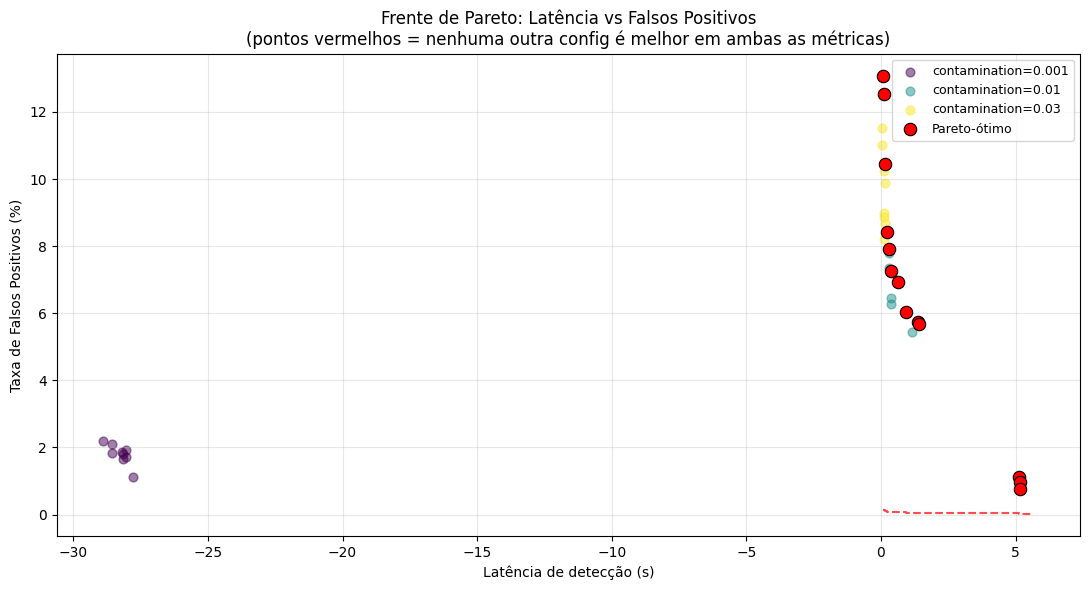

Configurações na frente de Pareto:
 contamination  n_estimators  max_features  max_samples  latency_s  fp_rate
         0.030           100           0.5          256   0.066421 0.130814
         0.030           150           0.5          256   0.106992 0.125469
         0.030           100           0.5          128   0.140502 0.104394
         0.010           100           0.5          128   0.232107 0.084210
         0.010           100           0.5          256   0.297196 0.079201
         0.010           100           0.7          256   0.387326 0.072660
         0.010           150           0.7          256   0.644177 0.069437
         0.010           150           1.0          256   0.938540 0.060430
         0.010           150           1.0          128   1.368895 0.057245
         0.010           100           1.0          128   1.394686 0.056775
         0.001           100           1.0          256   5.141280 0.011229
         0.001           150           1.0          2

In [8]:
def pareto_front(df, x_col, y_col):
    """Retorna máscara booleana das linhas na frente de Pareto (minimização de ambos)."""
    is_pareto = np.ones(len(df), dtype=bool)
    vals = df[[x_col, y_col]].values
    for i, (xi, yi) in enumerate(vals):
        if is_pareto[i]:
            dominated = (
                (vals[:, 0] <= xi) & (vals[:, 1] <= yi)
                & ((vals[:, 0] < xi) | (vals[:, 1] < yi))
            )
            dominated[i] = False
            is_pareto[dominated] = False
    return is_pareto


df_det = df_det.reset_index(drop=True)
df_det["pareto"] = pareto_front(df_det, "latency_s", "fp_rate")

contamination_vals = sorted(df_det["contamination"].unique())
cmap   = plt.cm.viridis
colors = {c: cmap(i / max(len(contamination_vals) - 1, 1)) for i, c in enumerate(contamination_vals)}

fig, ax = plt.subplots(figsize=(11, 6))

for c, grp in df_det.groupby("contamination"):
    ax.scatter(
        grp["latency_s"], grp["fp_rate"] * 100,
        color=colors[c], alpha=0.5, s=40, label=f"contamination={c}",
    )

pareto = df_det[df_det["pareto"]].sort_values("latency_s")
ax.scatter(
    pareto["latency_s"], pareto["fp_rate"] * 100,
    color="red", s=80, zorder=5, label="Pareto-ótimo",
    edgecolors="black", linewidths=0.8,
)
ax.step(
    pareto["latency_s"].tolist() + [pareto["latency_s"].max() + 0.5],
    pareto["fp_rate"].tolist() + [pareto["fp_rate"].iloc[-1]],
    where="post", color="red", linewidth=1.5, linestyle="--", alpha=0.7,
)

ax.set_xlabel("Latência de detecção (s)")
ax.set_ylabel("Taxa de Falsos Positivos (%)")
ax.set_title(
    "Frente de Pareto: Latência vs Falsos Positivos\n"
    "(pontos vermelhos = nenhuma outra config é melhor em ambas as métricas)"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Configurações na frente de Pareto:")
print(pareto[["contamination", "n_estimators", "max_features", "max_samples",
              "latency_s", "fp_rate"]].to_string(index=False))

## Impacto individual de cada parâmetro

Para entender a contribuição de cada parâmetro isoladamente,
agrupamos os resultados e calculamos a mediana da latência e do FP rate,
agregando sobre todos os outros parâmetros.

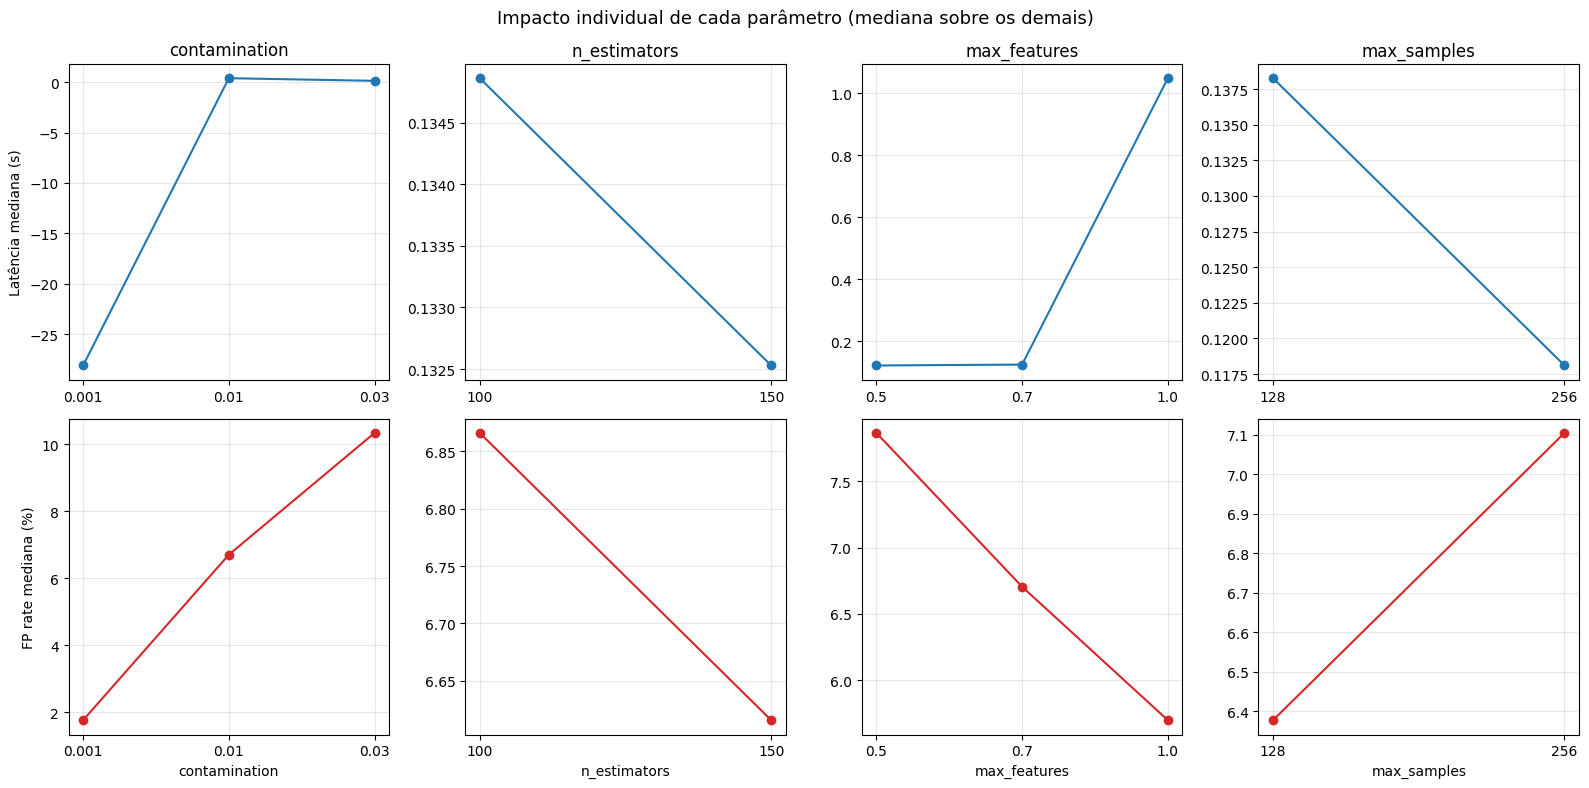

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
params_to_plot = ["contamination", "n_estimators", "max_features", "max_samples"]

for col, param in enumerate(params_to_plot):
    grp = df_det.groupby(param).agg(
        med_latency=("latency_s", "median"),
        med_fp_rate=("fp_rate", "median"),
    ).reset_index()

    ax_lat = axes[0, col]
    ax_fp  = axes[1, col]

    ax_lat.plot(grp[param].astype(str), grp["med_latency"], "o-", color="tab:blue")
    ax_lat.set_title(param)
    ax_lat.set_ylabel("Latência mediana (s)" if col == 0 else "")
    ax_lat.grid(True, alpha=0.3)

    ax_fp.plot(grp[param].astype(str), grp["med_fp_rate"] * 100, "o-", color="tab:red")
    ax_fp.set_ylabel("FP rate mediana (%)" if col == 0 else "")
    ax_fp.set_xlabel(param)
    ax_fp.grid(True, alpha=0.3)

fig.suptitle("Impacto individual de cada parâmetro (mediana sobre os demais)", fontsize=13)
plt.tight_layout()
plt.show()

## Heatmaps: interação entre parâmetros

Score composto mediano para pares de parâmetros, agregando sobre os demais.
Células mais escuras = melhor (menor score composto).

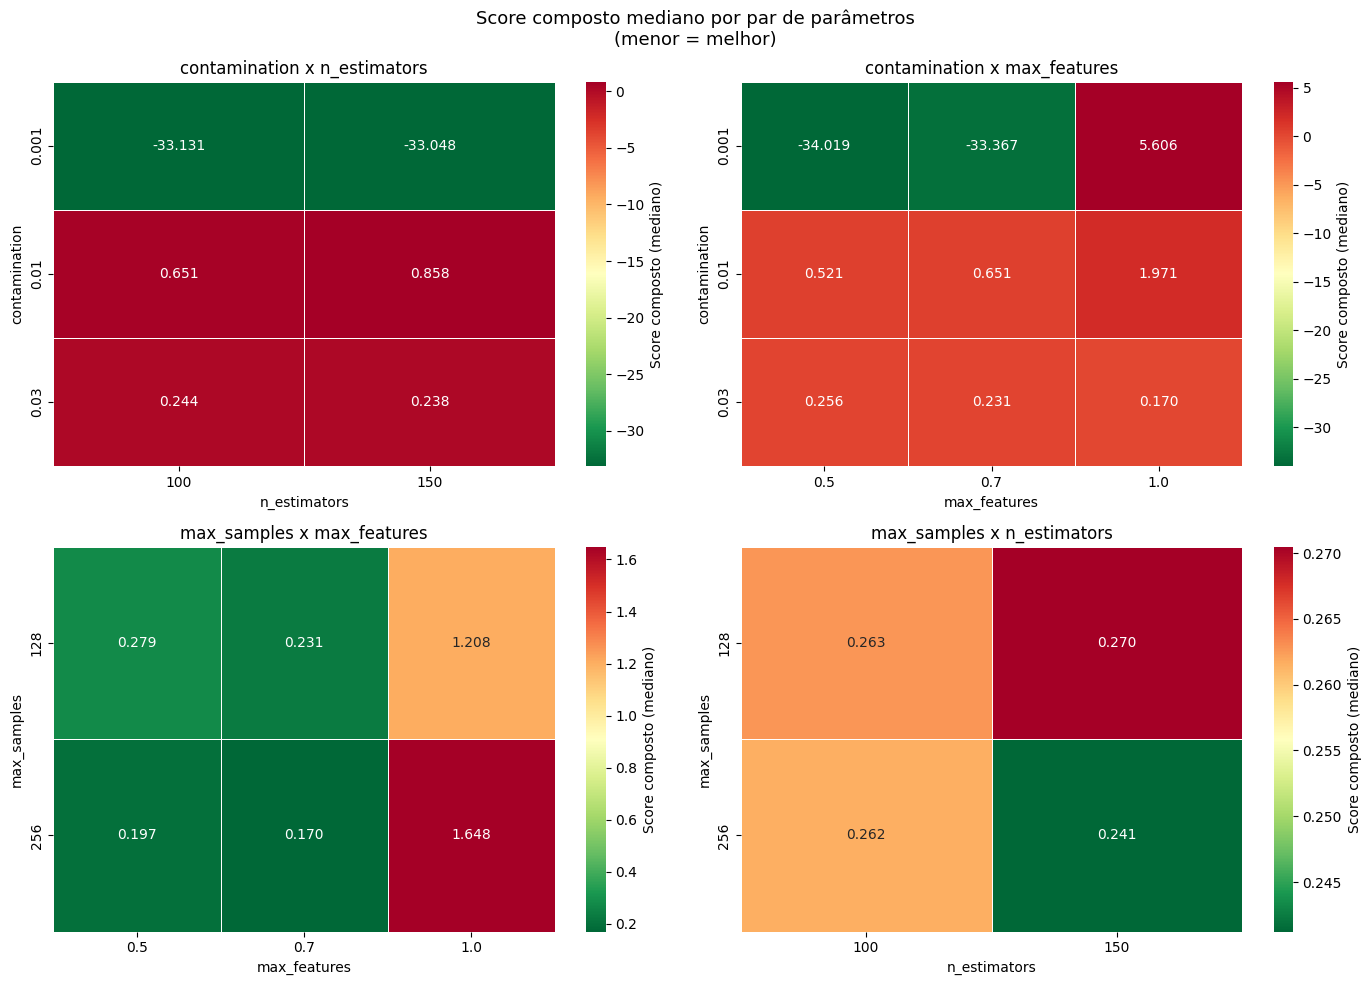

In [10]:
pairs = [
    ("contamination", "n_estimators"),
    ("contamination", "max_features"),
    ("max_samples",   "max_features"),
    ("max_samples",   "n_estimators"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (row_param, col_param) in zip(axes.flatten(), pairs):
    pivot = (
        df_det
        .groupby([row_param, col_param])["composite"]
        .median()
        .unstack(col_param)
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f",
        cmap="RdYlGn_r", linewidths=0.5,
        cbar_kws={"label": "Score composto (mediano)"},
    )
    ax.set_title(f"{row_param} x {col_param}")
    ax.set_xlabel(col_param)
    ax.set_ylabel(row_param)

fig.suptitle("Score composto mediano por par de parâmetros\n(menor = melhor)", fontsize=13)
plt.tight_layout()
plt.show()

## Melhor configuração — análise detalhada

Visualiza o comportamento temporal do modelo com a melhor combinação de parâmetros.

Melhor configuração (menor score composto):
  contamination: 0.001
  n_estimators: 100
  max_features: 0.5
  max_samples: 128
  latency_s: -28.881802159999992
  fp_count: 6318
  fp_rate: 0.021828207378334866
  composite: -35.18618183008519


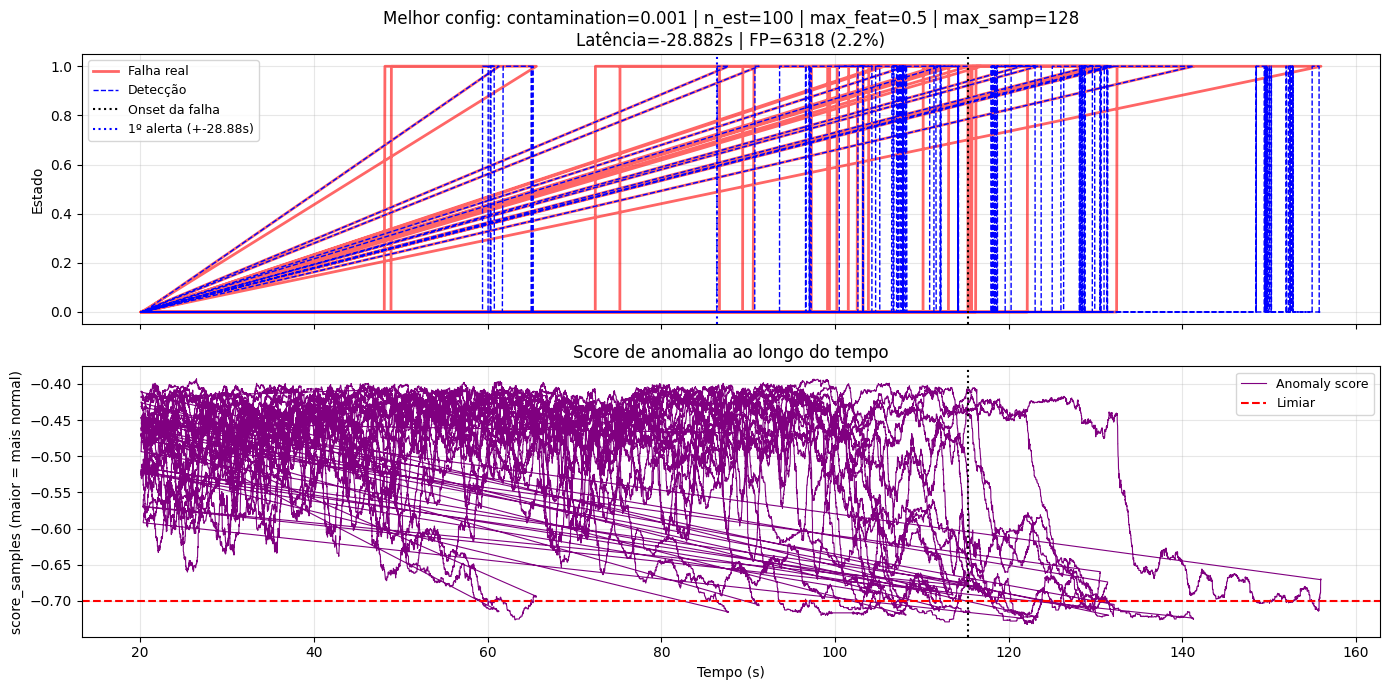

In [11]:
best = df_det.loc[df_det["composite"].idxmin()]
print("Melhor configuração (menor score composto):")
for k in ["contamination", "n_estimators", "max_features", "max_samples",
          "latency_s", "fp_count", "fp_rate", "composite"]:
    print(f"  {k}: {best[k]}")

best_model = IsolationForest(
    n_estimators=int(best["n_estimators"]),
    max_features=float(best["max_features"]),
    max_samples=int(best["max_samples"]),
    random_state=42,
    n_jobs=-1,
)
best_model.fit(X_train_scaled)

train_scores_best = best_model.score_samples(X_train_scaled)
test_scores_best  = best_model.score_samples(X_test_scaled)
threshold_best    = np.percentile(train_scores_best, 100 * best["contamination"])
y_pred_best       = (test_scores_best < threshold_best).astype(int)

post_fault = np.where(
    (y_pred_best == 1) & (np.arange(len(y_pred_best)) >= real_fault_idx)
)[0]
pred_fault_time = float(ts_test[post_fault[0]]) if len(post_fault) > 0 else None

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(ts_test, y_test,      color="red",  alpha=0.6, linewidth=2, label="Falha real")
axes[0].plot(ts_test, y_pred_best, color="blue", linestyle="--", linewidth=1, label="Detecção")
axes[0].axvline(real_fault_time, color="black", linewidth=1.5, linestyle=":", label="Onset da falha")
if pred_fault_time:
    axes[0].axvline(
        pred_fault_time, color="blue", linewidth=1.5, linestyle=":",
        label=f"1º alerta (+{best['latency_s']:.2f}s)",
    )
axes[0].set_ylabel("Estado")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(
    f"Melhor config: contamination={best['contamination']} | n_est={int(best['n_estimators'])} | "
    f"max_feat={best['max_features']} | max_samp={int(best['max_samples'])}\n"
    f"Latência={best['latency_s']:.3f}s | FP={int(best['fp_count'])} ({best['fp_rate']:.1%})"
)

axes[1].plot(ts_test, test_scores_best, color="purple", linewidth=0.8, label="Anomaly score")
axes[1].axhline(threshold_best, color="red", linestyle="--", linewidth=1.5, label="Limiar")
axes[1].axvline(real_fault_time, color="black", linewidth=1.5, linestyle=":")
axes[1].set_ylabel("score_samples (maior = mais normal)")
axes[1].set_xlabel("Tempo (s)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Score de anomalia ao longo do tempo")

plt.tight_layout()
plt.show()

## Conclusão

Para aplicar a melhor configuração encontrada, edite `conf/base/parameters.yml`:

```yaml
model_training:
  contamination: <melhor valor acima>
  n_estimators:  <melhor valor acima>
  # max_features e max_samples precisam ser expostos no pipeline
  # (ver nodes.py -> train_isolation_forest)
```

E rodar:
```
kedro run --pipeline=model_training
```

> **Nota:** `max_features` e `max_samples` ainda não são parâmetros configuráveis
> no pipeline Kedro. Para exposá-los, adicione-os em `parameters.yml` e passe-os
> para `train_isolation_forest` via `pipeline.py`.